In [11]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

data = pd.read_csv(r'D:\CSV_files\KNNAlgorithmDataset.csv')
x = data.drop('diagnosis',axis=1).values 
y = data['diagnosis'].values
imputer = SimpleImputer(strategy='mean')
X = imputer.fit_transform(x)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, shuffle = True)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=10)
# Train the classifier
knn.fit(X_train, y_train)
# Make predictions on the test set
y_pred = knn.predict(X_test)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: [31]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


In [12]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.956140350877193


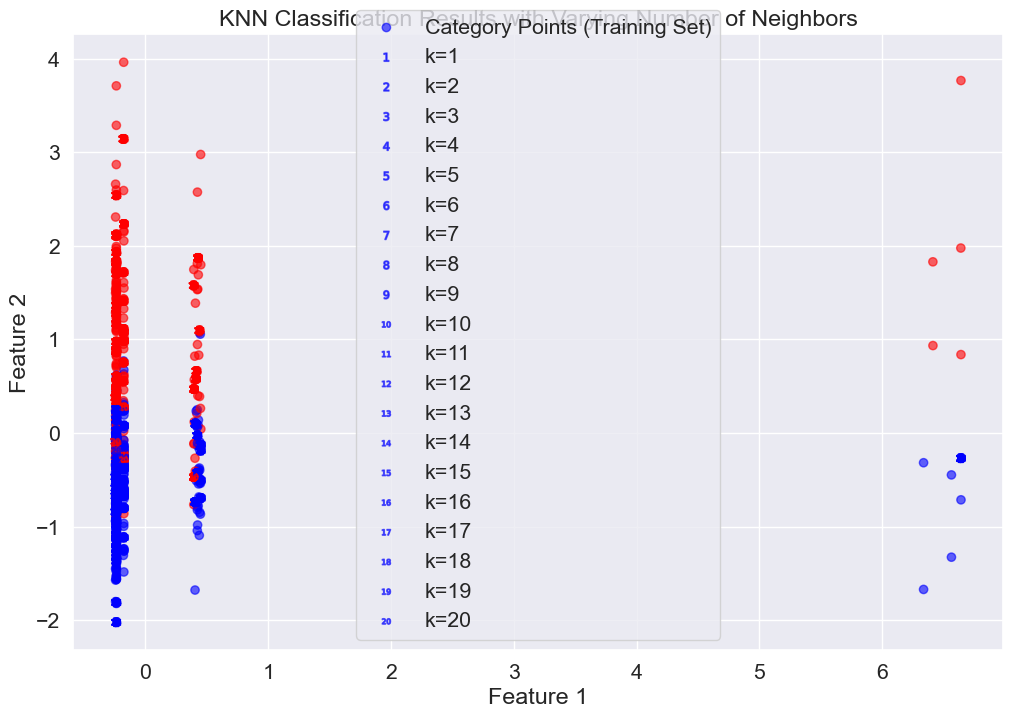

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Map category labels to colors
colors = {'B': 'blue', 'M': 'red'}

# Varying the number of neighbors from 1 to 20
neighbors = np.arange(1, 21)

# Initialize lists to store accuracies and predictions
accuracies = []
y_preds_list = []

# Loop through different values of n_neighbors
for n in neighbors:
    # Initialize the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=10)
    
    # Train the classifier
    knn.fit(X_train, y_train)
    
    # Make predictions on the test set
    y_pred = knn.predict(X_test)
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    
    # Store predictions
    y_preds_list.append(y_pred)

# Plot the scatter plot
plt.figure(figsize=(12, 8))

# Plot category points (training set)
plt.scatter(X_train[:, 0], X_train[:, 1], c=[colors[label] for label in y_train], label='Category Points (Training Set)', alpha=0.6)

# Plot new data points (test set) with predicted labels
for i, n in enumerate(neighbors):
    plt.scatter(X_test[:, 0], X_test[:, 1], c=[colors[label] for label in y_preds_list[i]], marker='${}$'.format(n), label='k={}'.format(n), alpha=0.6)

plt.title('KNN Classification Results with Varying Number of Neighbors')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

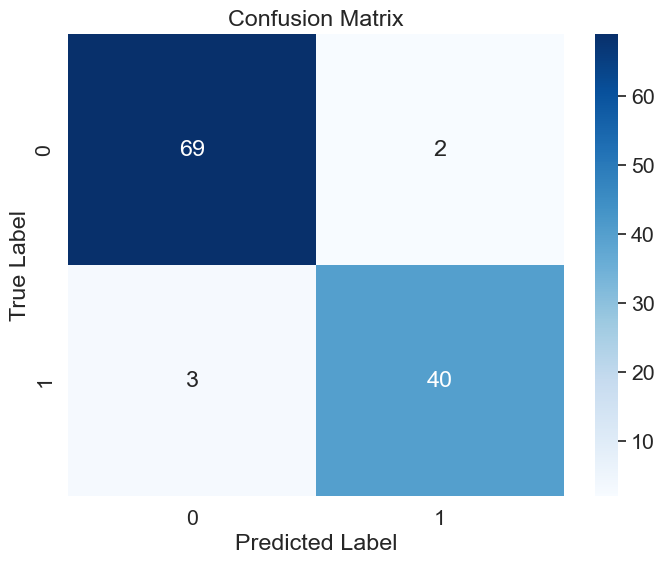

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


# Initialize the KNN classifier with the chosen value of n_neighbors
knn = KNeighborsClassifier(n_neighbors=10)

# Train the classifier
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn.predict(X_test)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='g')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
from sklearn.metrics import classification_report

knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

y_test_labels = y_test  
y_pred_labels = y_pred

# Create classification report
report = classification_report(y_test_labels, y_pred_labels)

print(report)

              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

